
## 1.  The Dunera Boys Archive 
   
The following notebook explores the Dunera Dataset, a collection of documents from the Jewish Museum of Australia, originally collected by Majer 'Ivan' Pietruschka, a Polish-born violinist and orchestra leader. The collection contains concert programs, photographs, and other documents from England and southeastern Australia (predominantly from wartime internment camps) over the period 1939-1944. Its name comes from the HMT Dunera, a ship which transported Pietruschka and other "enemy aliens" from England to Australia in 1940.



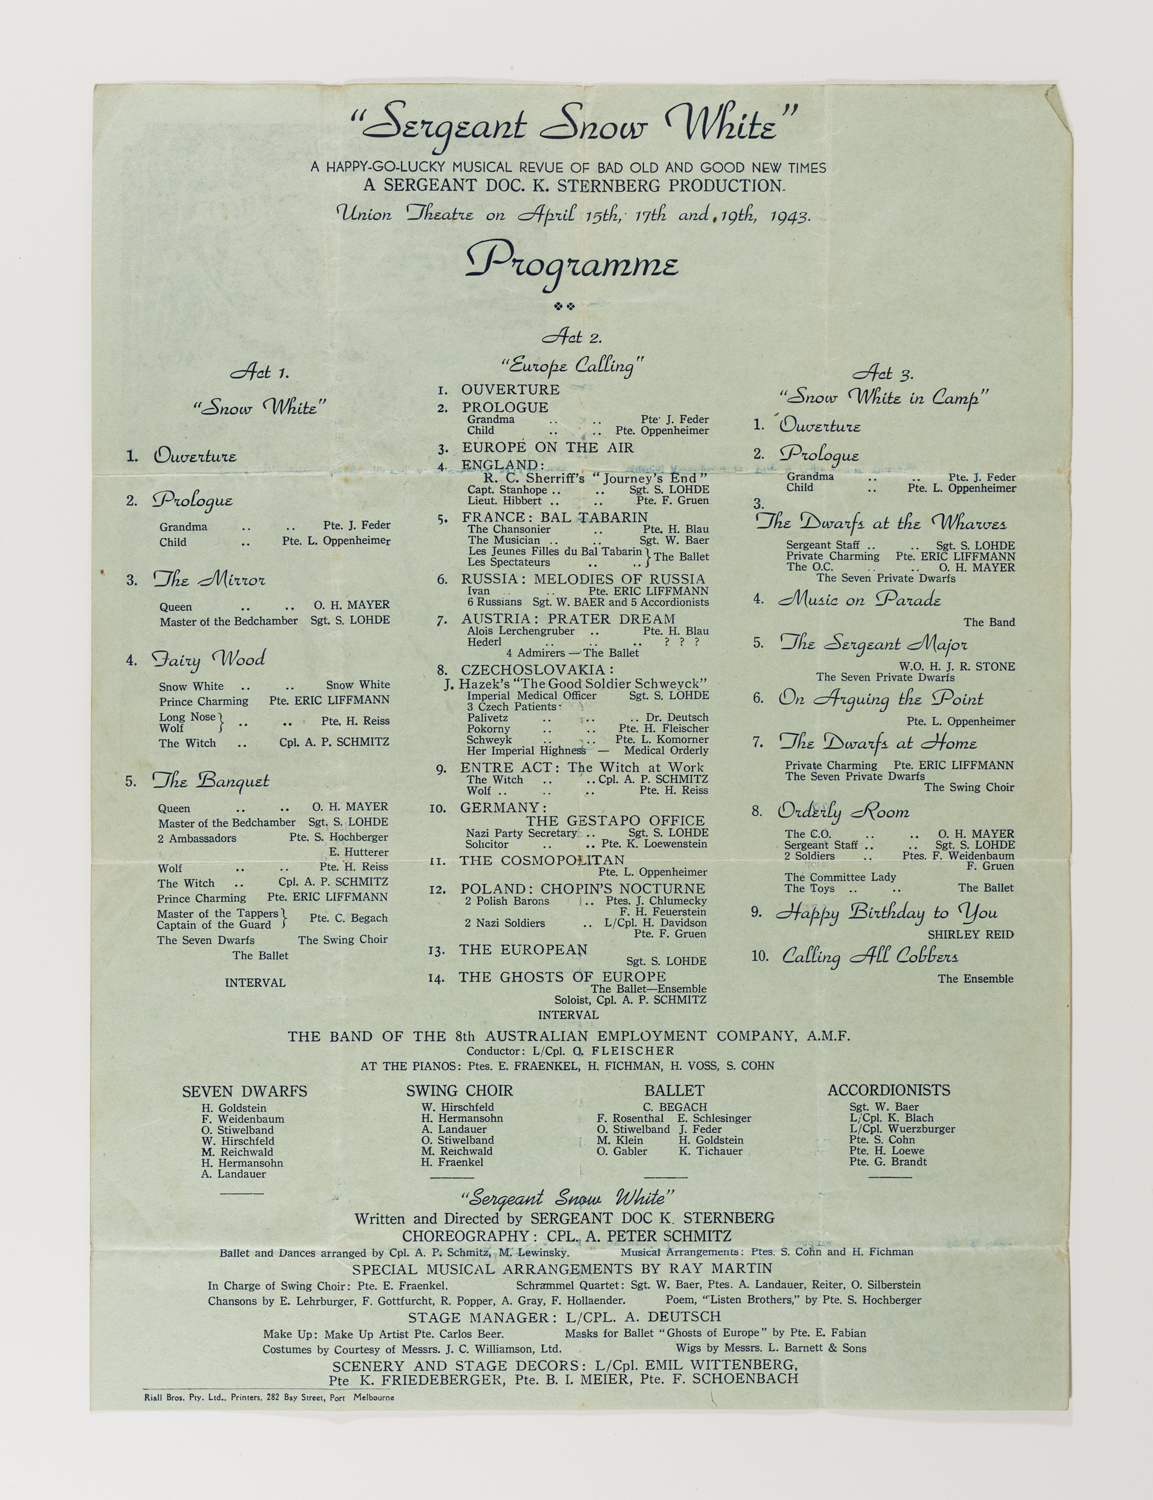
Example concert program from the dataset

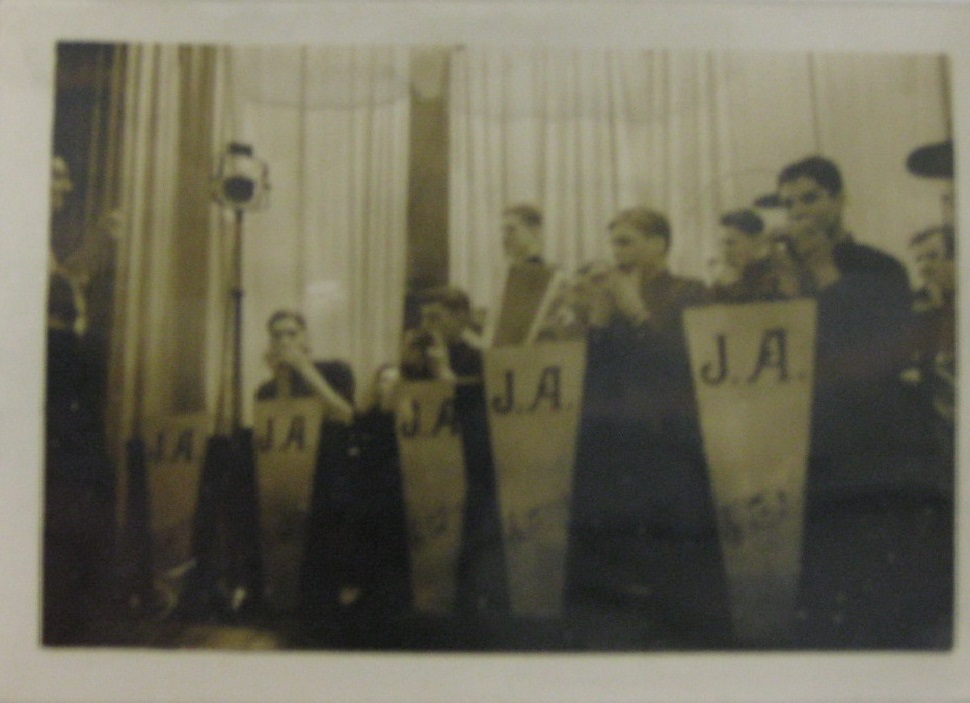

A photograph from the collection. Though not included in the data analysis later on in this notebook, the photos in the collection provide greater context to the concert information the dataset contains.



---

**Data Exploration**

Load in the data extracted from the Dunera concert programs. This process was done via Claude, formatting the information into a JSON file containing information about each performance.

In [ ]:
import json
with open("/content/jewish_concert_archive.json","r") as f:
  info=json.load(f)
events=info["concerts"]


Registers the user's OpenAI key (only nessesary if planning to use AI analysis/RAG feature).

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = input("OpenAI key: ")

Very basic retrevial-augmented generation implementation. A user can input a question about the dataset to be answered by a ChatGPT API.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model
llm = init_chat_model("gpt-4o-mini", model_provider='openai')
prompt="You are a musicologist analyzing a JSON file containing information about Jewish-Australian concert programs during wartime and internment. "+input()+" The following is the JSON data provided as a string. Use no other information in your response: "+str(events)
response = llm.invoke(prompt)
print(response.content)


Creates a network of performances from the dataset, with edges corresponding to shared credits (white) or shared songs (yellow). Node colors reflect the location of the performance (Hay Internment Camp, NSW - Blue; Tatura Internment Camp, VIC - Green; Malbourne, VIC - Cyan; Other Locations - Purple). Saves network as 'performance_network.html'. The connecting credits/songs can be viewed by hovering over the edge when viewing the html file.

Viewing the various performances in this way allows us to easily observe the connections which exist in the musical community of the internment camps during this time. It encourages the interpretation of these performances as elements of an ever-evolving artistic community, rather than isolated and unrelated events.  

In [ ]:
import plotly.graph_objects as go
import networkx as nx
import matplotlib.pyplot as plt
import pyvis
from pyvis import network as net

people=nx.Graph()
for i in range(len(events)):

  if events[i]["location"]=="Hay Internment Camp, New South Wales, Australia":
    c="blue"
  elif events[i]["location"]=="Tatura Internment Camp, Victoria, Australia":
    c="green"
  elif events[i]["location"]=="Melbourne, Victoria, Australia":
    c="cyan"
  else:
    c="purple"
  people.add_node(events[i]["title"],color=c,size=10)

elabels={}
for i in range(len(events)):
  for j in range(0,i):
    namelist=[]
    for k in events[i]["Complete credits"]:
      if k in events[j]["Complete credits"]:
        namelist.append(k)
    if len(namelist)>0:
      people.add_edge(events[i]["title"],events[j]["title"], color="white",title=", ".join(namelist), font_size=8)
        #elabels.update({(events[i]["title"],events[j]["title"]):k})
#pos = nx.spring_layout(people, k=0.6, iterations=20)
#nx.draw(people,pos,node_size=50,labels={node: node for node in people.nodes()},font_size=5,font_color="blue")
#nx.draw_networkx_edge_labels(people,pos,edge_labels=elabels,font_size=5)
s_by_a={}
for i in range(len(events)):
  s_by_a.update({events[i]["title"]:[]})
  if "acts" in events[i].keys():
    for j in events[i]["acts"]:
      for k in j["songs"]:
        s_by_a[events[i]["title"]].append(k["title"])
#print(s_by_a)
todo=[]
for i in s_by_a.keys():
  for j in todo:
    songs=[]
    for k in s_by_a[i]:
      if k in s_by_a[j]:
        #print(k)
        #print(i)
        #print(j)
        #print(s_by_a[j].index(k))
        songs.append(k)
    if len(songs)>0:
      people.add_edge(i,j, color="yellow",title=", ".join(songs), font_size=8)
  todo.append(i)
pyvis_graph = net.Network(notebook=True,
                          width="1000",
                          height="700",
                          bgcolor="black",
                          font_color="blue")

pyvis_graph.from_nx(people)
pyvis_graph.options.edges.smooth.enabled = True
for n in pyvis_graph.nodes:
    n["font"]={"size":9,"color":n["color"]}
pyvis_graph.show('performance_network.html')



Creates a heatmap-style chart showing the number of performances at locations throughout Australia between 1939-44. Saves chart as 'locations.png'.

In [ ]:
import pandas as pd
import seaborn as sbs
shorten={"Hay Internment Camp, New South Wales, Australia":"Hay Internment Camp, NSW","Tatura Internment Camp, Victoria, Australia":"Tatura Internment Camp, VIC","Melbourne, Victoria, Australia":"Melbourne, VIC"}
settings={"Hay Internment Camp, NSW":{},"Tatura Internment Camp, VIC":{},"Melbourne, VIC":{},"Other":{}}
for i in settings.keys():
  for j in ["1939","1940","1941","1942",'1943',"1944","Not specified"]:
    settings[i].update({j:0})
for i in range(len(events)):
  if events[i]["location"] not in ["Hay Internment Camp, New South Wales, Australia", "Tatura Internment Camp, Victoria, Australia", "Melbourne, Victoria, Australia"]:
    settings["Other"][events[i]["date"]]+=1
  else:
    settings[shorten[events[i]["location"]]][events[i]["date"]]+=1
chart=sbs.heatmap(pd.DataFrame(settings),annot=True,cbar=False,cmap="Blues")
chart.set_xticklabels(chart.get_xticklabels(), rotation=30)
fig = chart.get_figure()
fig.savefig("locations.png",bbox_inches = "tight")


